## DeepSpot Training

In this second notebook, we will provide the logic and a basic example of how to train DeepSpot on your spatial transcriptomics data. We assume that you have already preprocessed your data and prepared it for training.

In [1]:
import os
os.chdir('../../')

Export packages

In [2]:
from deepspot.utils.utils_image import get_morphology_model_and_preprocess
from deepspot.utils.utils import plot_loss_values

from deepspot.spot import DeepSpotDataLoader
from deepspot.spot import DeepSpot


from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from pathlib import Path
import lightning as L
import pandas as pd
import numpy as np
import torch
import yaml
yaml.Dumper.ignore_aliases = lambda *args : True

/scratch2/ig76/sasunih/conda/envs/deepspot/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Here, we specify the input parameters and the dataloader settings.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [4]:
samples = set(['ZEN38'])
out_folder = "example_data"

In [5]:
dataloader_param = {
# specify the used foundation model 
# to extract the precomputed tile representations
"morphology_model_name": "inception", 
"batch_size": 1024,
# use the spot, subspots, and neighboring spots.
'spot_context': 'spot_subspot_neighbors',
# the radius used to compute the neighbors around 
# the central spot based on the array coordinates.
'radius_neighbors': 1, 
# oversampling
'resolution': 1,
# if to normalize the data during training 
# and the type of normalization
'normalize': 'standard', # None
'augmentation': 'default' # to use 'aestetik' -> pip install aestetik;
        }
batch_size = dataloader_param["batch_size"]
image_feature_model = dataloader_param['morphology_model_name']
num_workers = max(1, torch.get_num_threads() - 1)

del dataloader_param["batch_size"]

In [6]:
genes = pd.read_csv(f"{out_folder}/data/info_highly_variable_genes_Visium.csv")
selected_genes_bool = genes.isPredicted.values
genes_to_predict = genes[selected_genes_bool]
genes_to_predict

,gene_ids,feature_types,genome,mito,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_counts,gene_symbol,gene_name,highly_variable,highly_variable_rank,means,variances,variances_norm,isPredicted
5,ENSG00000228794,Gene Expression,GRCh38,False,41,0.118863,0.112313,89.405685,46.0,3.850148,46.0,LINC01128,LINC01128,True,3823.0,0.118863,0.136094,1.047740,True
9,ENSG00000187634,Gene Expression,GRCh38,False,45,0.134367,0.126075,88.372093,52.0,3.970292,52.0,SAMD11,SAMD11,True,2440.0,0.134367,0.163246,1.105444,True
13,ENSG00000272512,Gene Expression,GRCh38,False,12,0.036176,0.035537,96.899225,14.0,2.708050,14.0,AL645608.7,AL645608.7,True,1402.0,0.036176,0.045320,1.189554,True
14,ENSG00000188290,Gene Expression,GRCh38,False,130,0.521964,0.420002,66.408269,202.0,5.313206,202.0,HES4,HES4,True,794.0,0.521964,0.840838,1.311193,True
15,ENSG00000187608,Gene Expression,GRCh38,False,168,0.671835,0.513922,56.589147,260.0,5.564520,260.0,ISG15,ISG15,True,2010.0,0.671835,0.972339,1.130697,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19775,ENSG00000212907,Gene Expression,GRCh38,True,275,1.896641,1.063552,28.940568,734.0,6.599871,734.0,MT-ND4L,MT-ND4L,True,1894.0,1.896641,3.911569,1.137800,True
19776,ENSG00000198886,Gene Expression,GRCh38,True,387,46.855297,3.868182,0.000000,18133.0,9.805544,18133.0,MT-ND4,MT-ND4,True,484.0,46.855297,1858.295069,1.461353,True
19777,ENSG00000198786,Gene Expression,GRCh38,True,335,3.361757,1.472875,13.436693,1301.0,7.171657,1301.0,MT-ND5,MT-ND5,True,924.0,3.361757,10.873974,1.277749,True
19779,ENSG00000198727,Gene Expression,GRCh38,True,387,27.043928,3.333772,0.000000,10466.0,9.255982,10466.0,MT-CYB,MT-CYB,True,671.0,27.043928,539.850397,1.354743,True


We need the feature_dim when defining the DeepSpot input dimensions

In [7]:
_, _, feature_dim = get_morphology_model_and_preprocess(model_name=image_feature_model, 
                                                                                device=device)
feature_dim

2048

Now, we prepare the DeepSpot dataloader. `out_folder` specifies the parent location where the preprocessed data is stored. `genes_to_keep` is a boolean np.array that indicates which genes to include for training and prediction. `samples` refers to the slide_ids, which are used to load the data.

In [8]:
train_data_loader_custom = DeepSpotDataLoader(
                               out_folder=out_folder, 
                               samples=samples, 
                               genes_to_keep=selected_genes_bool,
                               **dataloader_param
)
train_data_loader = torch.utils.data.DataLoader(dataset=train_data_loader_custom,
                                                      batch_size=batch_size,
                                                      num_workers=num_workers,
                                                      shuffle=True)

100%|██████████| 1/1 [00:07<00:00,  7.77s/it]

Resampling with resolution 1...


Here, you can customize the hyperparameters of DeepSpot. For this example, we will train it using the default parameters. The `scaler` is important to be the same as the one used during training, so that the predictions of DeepSpot can be rescaled back to their original ranges using the `inverse_transform` function. 

##### IMPORTANT: Remember to manually rescale the values, as this is not done automatically.
```
expression_norm = model(X)
expression_norm should be np.array
expression = model.inverse_transform(expression_norm)
```

In [9]:
param = {

        }
param

{}

In [10]:
regressor = DeepSpot(input_size=feature_dim,
                output_size=int(selected_genes_bool.sum()),
                scaler=train_data_loader_custom.scaler,
                **param)

We train the model with early stoppping.

In [11]:
trainer = L.Trainer(max_epochs=10, logger=False, enable_checkpointing=False, callbacks=[EarlyStopping(monitor="train_step",
                                                                    patience=3,
                                                                    min_delta=0.01, 
                                                                    mode="min")])
trainer.fit(regressor, train_data_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/scratch2/ig76/sasunih/conda/envs/deepspot/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ phi_spot │ ModuleList │ 10.5 M │ train │     0 │
│ 1 │ rho      │ ModuleList │ 76.8 M │ train │     0 │
└───┴──────────┴────────────┴────────┴───────┴───────┘

Trainable params: 87.3 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 87.3 M                                                                                               
Total estimated model params size (MB): 349.364                                                                    
Modules in train mode: 112                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

SLURM auto-requeueing enabled. Setting signal handlers.
/scratch2/ig76/sasunih/conda/envs/deepspot/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


/scratch2/ig76/sasunih/conda/envs/deepspot/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

We also provide a function to visualize your training loss. Keep in mind that this is only an example

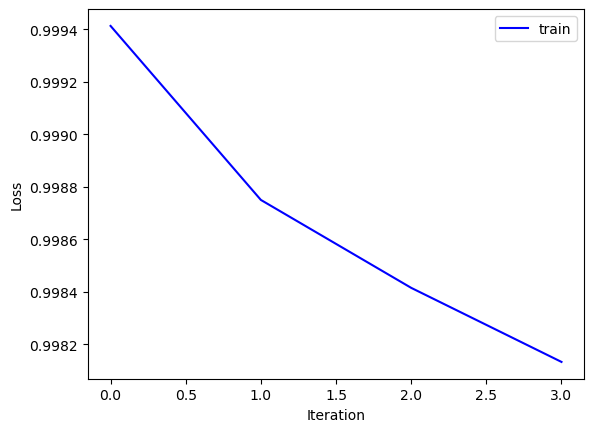

In [12]:
plot_loss_values(regressor.training_loss)

Once DeepSpot is trained, you can export its weights and hyperparameters and use them for inference.

In [13]:
Path(f"pretrained_model_weights/example_model").mkdir(parents=True, exist_ok=True)

In [14]:
model_path = 'pretrained_model_weights/example_model/weights_Visium.pkl'
torch.save(regressor, model_path)

In [15]:
hparam = dict(regressor.hparams)
hparam['image_feature_model'] = dataloader_param['morphology_model_name']
hparam['scaler'] = str(hparam['scaler']) # ignore since it is an object

In [16]:
# Specify the output YAML file path
yaml_file_path = 'pretrained_model_weights/example_model/hparam_Visium.yaml'

# Save the dictionary as a YAML file
with open(yaml_file_path, 'w') as yaml_file:
    yaml.dump(hparam, yaml_file)